# 5. Feature Engineering

Feature engineering is choosing which columns the model sees, and inventing new ones. It has a reputation as the highest-leverage activity in applied machine learning, and on the right dataset that is true.

This chapter applies the whole toolkit to the diabetes data and finds that **every single technique makes the model worse**. That is the real result, and understanding why is worth more than a manufactured win. Then we move to the kind of data where feature selection earns its reputation — and where it can also produce a model that is 82% accurate on pure noise.

**You will learn:**

- the three kinds of feature engineering, and when each applies
- how to score and select features, and how to read those scores
- why none of it helps a dataset with eight curated columns
- the leakage demonstration promised in chapters 3 and 4

**Prerequisites:** chapters 3 and 4.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tuiml.datasets import load_diabetes
from tuiml.workflow import Workflow
from tuiml.preprocessing import SimpleImputer, StandardScaler
from tuiml.algorithms.trees import RandomForestClassifier
from tuiml.evaluation import cross_val_score, StratifiedKFold

data = load_diabetes()
y = data.y

X = data.X.copy()
for name in ["plas", "pres", "skin", "insu", "mass"]:
    col = data.feature_names.index(name)
    X[X[:, col] == 0, col] = np.nan

splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
impute = lambda: SimpleImputer(strategy="median")
forest = lambda: RandomForestClassifier(n_estimators=200, random_state=42)


def score(steps):
    """Cross-validated accuracy for a pipeline given as a list of steps."""
    return cross_val_score(Workflow(steps), X, y, cv=splitter).mean()


baseline = score([impute(), forest()])
print(f"baseline (impute + forest): {baseline:.4f}")

baseline (impute + forest): 0.7695


## 5.1 Three kinds

**Selection** keeps a subset of the columns you already have and discards the rest. Fewer features means faster training, less overfitting, and a model you can explain.

**Extraction** builds a smaller set of new columns that summarise the old ones — PCA and friends. You keep the information and lose the interpretability.

**Generation** invents new columns from existing ones: products, ratios, powers, bins. This is where domain knowledge enters, and it is the only one of the three that can add information the model could not otherwise reach.

All three are `Transformer`s, so they slot into a `Workflow` and get fitted inside the fold, exactly like chapter 4's imputer.

## 5.2 Selection

`SelectKBestSelector` scores every feature against the target and keeps the top *k*.

In [2]:
from tuiml.features.selection import SelectKBestSelector

# Fit on imputed data just to read the scores. (In a pipeline this happens
# inside the fold — see section 5.5 for why that distinction is not pedantry.)
X_imputed = SimpleImputer(strategy="median").fit_transform(X.copy())

selector = SelectKBestSelector(k=4).fit(X_imputed, y)
scores = selector.get_feature_scores()

order = np.argsort(scores)[::-1]
for rank, idx in enumerate(order, 1):
    keep = "keep" if idx in selector.get_selected_indices() else ""
    print(f"  {rank}. {data.feature_names[idx]:6s} {scores[idx]:7.1f}  {keep}")

  1. plas     245.7  keep
  2. mass      82.6  keep
  3. age       46.1  keep
  4. preg      39.7  keep
  5. skin      37.1  
  6. insu      33.2  
  7. pedi      23.9  
  8. pres      21.6  


Plasma glucose dominates by a factor of three over the next feature, which is exactly what a clinician would tell you — it is close to being the definition of the condition being predicted. The selector has rediscovered domain knowledge from the data, which is a good sign that the scoring is working.

Now the question that matters: does dropping the other four features help?

In [3]:
from tuiml.features.selection import CFSSelector, VarianceThresholdSelector

results = {
    "baseline — all 8 features": baseline,
    "SelectKBest, k=6": score([impute(), SelectKBestSelector(k=6), forest()]),
    "SelectKBest, k=4": score([impute(), SelectKBestSelector(k=4), forest()]),
    "CFS (correlation-based)": score([impute(), CFSSelector(), forest()]),
}

for label, value in results.items():
    delta = value - baseline
    print(f"  {label:28s} {value:.4f}  {delta:+.4f}")

  baseline — all 8 features    0.7695  +0.0000
  SelectKBest, k=6             0.7500  -0.0195
  SelectKBest, k=4             0.7435  -0.0260
  CFS (correlation-based)      0.7448  -0.0247


Every one of them loses. Not by much, but consistently, and in the direction opposite to the one the technique promises.

The explanation is in the dataset's provenance. These eight columns are not a raw data dump — they are the variables a research team selected in 1988 because they believed each one carried signal. There is no junk to remove. Dropping `insu` and `pedi` does not remove noise, it removes information, and the forest was already perfectly capable of ignoring a weak feature by simply not splitting on it.

> **Remark — feature selection is a treatment for a specific disease.** That disease is having more columns than you have reason to trust: hundreds of sensor readings, thousands of gene expressions, a wide join that dragged in every column of a dimension table. On eight curated features, there is nothing to cure.

## 5.3 Extraction

`PCAExtractor` rotates the feature space so that the first component captures as much variance as possible, the second as much of the rest, and so on. Keep the first few and you have compressed the data.

PCA is distance-based, so it needs scaled input — chapter 3's rule applies.

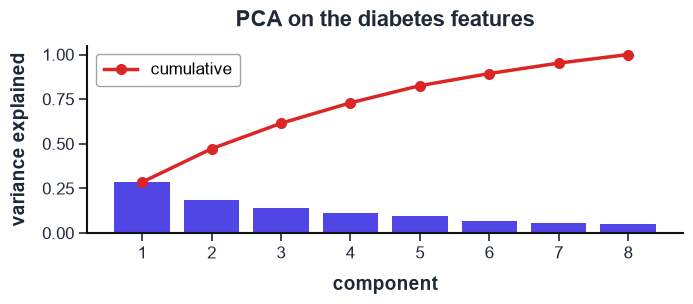

first 4 components explain 73.0% of the variance


In [4]:
from tuiml.features.extraction import PCAExtractor

pca = PCAExtractor(n_components=8).fit(StandardScaler().fit_transform(X_imputed))
variance = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(range(1, 9), variance, color="#4f46e5")
ax.plot(range(1, 9), np.cumsum(variance), color="#dc2626", marker="o", label="cumulative")
ax.set_xlabel("component")
ax.set_ylabel("variance explained")
ax.set_title("PCA on the diabetes features")
ax.legend()
plt.show()

print("first 4 components explain", f"{np.cumsum(variance)[3]:.1%}", "of the variance")

In [5]:
pca_score = score([impute(), StandardScaler(), PCAExtractor(n_components=4), forest()])
print(f"PCA to 4 components: {pca_score:.4f}  ({pca_score - baseline:+.4f})")

PCA to 4 components: 0.7382  (-0.0313)


Worse again, and for a reason that generalises: **PCA maximises variance, not predictive power.** Nothing in the procedure looks at `y`. A direction in which patients differ a lot may be a direction that says nothing about diabetes, and the fourth component — the one we discarded — may have been carrying most of the signal.

PCA earns its place when you have hundreds of correlated columns and need to make the problem tractable, or when you want a 2-D picture of your data. It is not a general accuracy improvement.

## 5.4 Generation

Generation is the one that can add information rather than rearrange it.

In [6]:
from tuiml.features.generation import (
    InteractionFeaturesGenerator,
    PolynomialFeaturesGenerator,
    MathematicalFeaturesGenerator,
)

interactions = InteractionFeaturesGenerator().fit_transform(X_imputed.copy())
polynomial = PolynomialFeaturesGenerator(degree=2).fit_transform(X_imputed.copy())

print(f"original    : {X_imputed.shape[1]:3d} features")
print(f"interactions: {interactions.shape[1]:3d} features  (every pairwise product)")
print(f"polynomial 2: {polynomial.shape[1]:3d} features  (products and squares)")

original    :   8 features
interactions:  36 features  (every pairwise product)
polynomial 2:  45 features  (products and squares)


In [7]:
gen_results = {
    "baseline": baseline,
    "+ pairwise interactions": score([impute(), InteractionFeaturesGenerator(), forest()]),
    "+ polynomial, degree 2": score([impute(), PolynomialFeaturesGenerator(degree=2), forest()]),
}

for label, value in gen_results.items():
    print(f"  {label:26s} {value:.4f}  {value - baseline:+.4f}")

  baseline                   0.7695  +0.0000
  + pairwise interactions    0.7591  -0.0104
  + polynomial, degree 2     0.7512  -0.0183


Also worse — and this one is the least surprising of the three. A random forest builds interactions natively: a path down a tree that splits on glucose and then on BMI *is* a glucose-BMI interaction. We handed the model 28 extra columns describing things it could already express, and diluted the random feature sampling that makes a forest work.

Generated features pay off with models that cannot build interactions themselves — linear and logistic regression above all. The honest version of the advice is: **generate features to compensate for a model's limitations, not as a reflex.**

`MathematicalFeaturesGenerator` applies named transforms (`log`, `sqrt`, `square`, `reciprocal`) and is the right tool when you have a reason to believe a relationship is multiplicative rather than additive:

In [8]:
maths = MathematicalFeaturesGenerator(transformations=["log", "sqrt"], include_original=True)
transformed = maths.fit_transform(X_imputed.copy())

print(f"{X_imputed.shape[1]} features -> {transformed.shape[1]} after adding log and sqrt")

8 features -> 24 after adding log and sqrt


## 5.5 The leakage demonstration

Chapters 3 and 4 promised this. Here it is.

We build a dataset with **no signal whatsoever**: 100 rows, 3000 columns of pure Gaussian noise, and labels from a coin flip. There is nothing to learn. Any honest evaluation must land at 0.5.

In [9]:
rng = np.random.default_rng(0)

X_noise = rng.normal(size=(100, 3000))
y_noise = rng.integers(0, 2, size=100)

print("100 rows, 3000 random features, random labels")
print("correlation between any feature and y is chance alone")

100 rows, 3000 random features, random labels
correlation between any feature and y is chance alone


Now the mistake — and note how reasonable it looks. Select the 20 best features. Then cross-validate a model on those 20 features, carefully, with stratified folds.

In [10]:
# WRONG: the selector sees every row and every label before the split.
leaky_selector = SelectKBestSelector(k=20)
X_preselected = leaky_selector.fit_transform(X_noise, y_noise)

noise_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
leaky = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=0),
    X_preselected, y_noise, cv=noise_splitter,
).mean()

print(f"accuracy after selecting features up front: {leaky:.4f}")

accuracy after selecting features up front: 0.8187


**82% accuracy on random noise.** The cross-validation was real, the folds were stratified, the model never saw a test row during training. And the result is meaningless.

Here is what happened. Out of 3000 random columns, some will correlate with the labels by luck — with only 100 rows, some will correlate *well*. The selector searched all 3000 and kept the twenty luckiest. But it measured that luck using **all 100 labels**, including the ones later used for testing. Each fold's test labels had already helped choose the features, so the "unseen" test set was never unseen.

Put the selector inside the pipeline and the illusion evaporates:

In [11]:
honest_pipeline = Workflow([
    SelectKBestSelector(k=20),
    RandomForestClassifier(n_estimators=100, random_state=0),
])

honest = cross_val_score(honest_pipeline, X_noise, y_noise, cv=noise_splitter).mean()

print(f"selection inside the fold: {honest:.4f}")
print(f"selection before the split: {leaky:.4f}")
print(f"\ntruth: 0.5000 — there is no signal in this data")

selection inside the fold: 0.5300
selection before the split: 0.8187

truth: 0.5000 — there is no signal in this data


Now each fold re-runs the selection on its own training rows, picks whatever twenty columns are lucky *there*, and those columns turn out to predict nothing on the held-out rows. The result sits at chance, which is correct.

The gap is roughly thirty points, conjured out of nothing.

> **Remark — this is not a rare failure.** It is one of the most common serious errors in applied machine learning, and it is most dangerous exactly where feature selection is most tempting: wide data with few rows, which describes most genomics, most sensor work, and a great deal of finance. The 82% would survive code review, because every individual line is defensible.

The defence is structural rather than vigilant: **put every fitted step inside the `Workflow`.** Chapter 4's argument was that pipelines make the correct thing automatic. This is what that buys you.

## 5.6 So when does it help?

Nothing in this chapter improved the diabetes model. That is a fact about the dataset, not a verdict on the techniques. The conditions under which each one pays:

| Technique | Pays off when | Warning |
|---|---|---|
| Selection | Many columns, unknown quality, or redundancy | Devastating leakage risk if fitted outside the fold |
| Extraction (PCA) | Hundreds of correlated columns; visualisation | Ignores `y`; can discard the signal |
| Generation | Model cannot express interactions (linear models) | Redundant for trees and forests |
| Domain features | Always, if you have the knowledge | Requires you to understand the problem |

The last row is the one that matters most and the only one this book cannot give you a function for. A `glucose × BMI` term invented by someone who understands metabolic syndrome will beat anything in this notebook. `PolynomialFeaturesGenerator` will also produce that term — buried among 36 others, with no reason to single it out.

And the meta-lesson, which is the same as chapter 3's: **measure.** Every technique here is one `score(...)` call away from being tested rather than assumed.

## Recap

- Three kinds: **selection** (drop columns), **extraction** (compress them), **generation** (invent them).
- `SelectKBestSelector` ranks features against the target; `get_feature_scores()` shows the ranking, and here it correctly identifies plasma glucose as dominant.
- On eight curated features, **selection, PCA and generated features all made the model worse.** There was no junk to remove and no interaction a forest could not already build.
- PCA maximises variance, not predictive power — it never looks at `y`.
- Generate features to compensate for a model's limitations; trees do not need them.
- **Feature selection outside the fold scored 82% on pure noise.** Inside a `Workflow`, the same data scores 53%, which is the truth.
- Every technique here is testable in one line. Test rather than assume.

**Next:** chapter 6 turns to the class imbalance we have been noting since chapter 1, and finds the second transform where fold discipline is worth tens of points rather than thousandths.